<a href="https://colab.research.google.com/github/brielcastelo/Analise-dos-Dados-da-Netflix/blob/main/Netflix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **0. Introdução**

Vamos análisar o catalogo de filmes da Netflix por meio de um dataset disponiblizado pelo Kaggle.

Por meio desse notebook iremos fazer uma limpeza e preparação dos dados, além de tentar responder algumas perguntas acerca de como é feita o catalogo de filmes da Netflix.

Algumas das perguntas inclui:

*   Qual é a principal faixa etária disponivel
*   A distribuição de filmes e séries durante os anos
*   A porcentagem de filmes estrangeiros
-
-
*   ...

Dataset utilizado: https://www.kaggle.com/code/joshuaswords/netflix-data-visualization/notebook


# **1. Importação das bibliotecas e dos dados.**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import numpy as np

In [ ]:
df = pd.read_csv('/content/netflix_titles.csv')

In [ ]:
df.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


# **2. Limpeza e organização dos dados**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
for i in df.columns:
  percent = df[i].isna().sum() / df[i].value_counts().sum() * 100
  if percent != 0:
    print("{} porcentagem de nulo: {}%".format(i, percent.round(2)))

director porcentagem de nulo: 42.67%
cast porcentagem de nulo: 10.34%
country porcentagem de nulo: 10.42%
date_added porcentagem de nulo: 0.11%
rating porcentagem de nulo: 0.05%
duration porcentagem de nulo: 0.03%


Por meio desse código, conseguimos ter um panorama da sujeira dos dados e o que devemos limpar. Com base nisso, iremos fazer o seguinte:
- Excluir os registros nulos das colunas onde a porcentagem de nulo é
menos de 1%.
- Excluir as linhas que possuem valores duplicados.
- Modificar os valores nulos com algo que podemos ter algum insight.

In [ ]:
df['director'] = df['director'].fillna('No Data')
df['cast'] = df['cast'].fillna('No Data')
df['country'] = df['country'].fillna(df['country'].mode())

In [ ]:
df = df.dropna()
df = df.drop_duplicates()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7961 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7961 non-null   object
 1   type          7961 non-null   object
 2   title         7961 non-null   object
 3   director      7961 non-null   object
 4   cast          7961 non-null   object
 5   country       7961 non-null   object
 6   date_added    7961 non-null   object
 7   release_year  7961 non-null   int64 
 8   rating        7961 non-null   object
 9   duration      7961 non-null   object
 10  listed_in     7961 non-null   object
 11  description   7961 non-null   object
dtypes: int64(1), object(11)
memory usage: 808.5+ KB


Vou excluir a coluna "show_id" porque ela não passa nenhuma informação e o dataset fica mais compacto. Caso a gente precise selecionar um registro especifico é só utilizarmos o index.

In [ ]:
df = df.drop('show_id', axis=1)

Como estamos fazendo uma análise em português, será interessante também traduzir as colunas para que ela fique claro para todos os públicos.

In [ ]:
colunas_pt = ['tipo', 'titulo', 'diretor', 'elenco', 'pais', 'data_adicionada', 'lançamento', 'classificação_indicativa', 'duração', 'generos', 'descrição']

In [ ]:
df.columns = colunas_pt

# **3. Tratamento dos dados**

Eliminamos os valores nulos porém não terminou o problema. Existem algumas variáveis que precisamos tratar antes de fazer as análises.


A coluna "data_adicionada" que é bom ter as suas informações dividias para que a gente possa ter mais liberdade na hora de fazer as análises.

In [ ]:
df['data_adicionada'] = pd.to_datetime(df['data_adicionada'], format='mixed')

In [ ]:
df['mês'] = df['data_adicionada'].dt.month_name()
df['ano'] = df['data_adicionada'].dt.year

A coluna "classificação_indicativa" possui a classificação indicativa natural dos estados unidos, e é separado entre filmes e programas de televisão. Para facilitar a apresentação, eu vou converter todos os valores para o Classind, que é o sistema de classificação indicativa brasileiro, com algumas adaptações

In [ ]:
df['classificação_indicativa'].unique()

array(['PG-13', 'TV-MA', 'TV-14', 'TV-Y7', 'PG', 'R', 'TV-PG', 'TV-Y',
       'TV-G', 'G', 'NC-17', 'NR', 'TV-Y7-FV', 'UR'], dtype=object)

In [ ]:
Rating_Order = ["G", "PG", "PG-13", "R", "NC-17", 'NR', 'UR']
TV_rating = ['TV-G', 'TV-Y', 'TV-Y7', 'TV-PG', 'TV-14', 'TV-MA', 'TV-Y7-FV']

In [ ]:
df['classificação_indicativa'] = df['classificação_indicativa'].replace(Rating_Order, ['L', '10 anos', '14 anos', '16 anos', '18 anos', 'Não Classificado', 'Não Classificado'])
df['classificação_indicativa'] = df['classificação_indicativa'].replace(TV_rating, ['L', '6 anos', '10 anos', '12 anos', '14 anos', '16 anos', '10 anos'])

In [ ]:
df['classificação_indicativa'].unique()

array(['14 anos', '16 anos', '10 anos', '12 anos', '6 anos', 'L',
       '18 anos', 'Não Classificado'], dtype=object)

A coluna generos contém listas com mais de um genero, porém a quantidade de generos é variada, então vamos retirar apenas o primeiro item para facilitar a nossa análise

In [ ]:
df['generos'].value_counts()

,count
generos,
Documentaries,343
"Dramas, International Movies",337
Stand-Up Comedy,303
"Comedies, Dramas, International Movies",260
"Dramas, Independent Movies, International Movies",243
...,...
"Action & Adventure, Cult Movies",1
"Action & Adventure, Comedies, Music & Musicals",1
"Classic Movies, Horror Movies, Thrillers",1


In [ ]:
df['generos'] = df['generos'].str.split(',').str[0]

In [ ]:
df['generos'].unique()

array(['Documentaries', 'International TV Shows', 'Dramas',
       'British TV Shows', 'Comedies', 'TV Comedies', 'Crime TV Shows',
       'Docuseries', 'Horror Movies', 'Thrillers', "Kids' TV",
       'Action & Adventure', 'Reality TV', 'Anime Series',
       'Sci-Fi & Fantasy', 'Children & Family Movies', 'Classic Movies',
       'TV Dramas', 'Stand-Up Comedy', 'TV Action & Adventure',
       'TV Shows', 'Movies', 'Classic & Cult TV', 'Romantic TV Shows',
       'International Movies', 'Stand-Up Comedy & Talk Shows',
       'Cult Movies', 'Independent Movies', 'TV Horror',
       'Spanish-Language TV Shows', 'Music & Musicals', 'Romantic Movies',
       'Anime Features', 'LGBTQ Movies', 'TV Sci-Fi & Fantasy',
       'Sports Movies'], dtype=object)

Da mesma forma acontece com a variavel "pais".

In [ ]:
df['pais'].value_counts()

,count
pais,
United States,2809
India,972
United Kingdom,418
Japan,243
South Korea,199
...,...
"Mexico, United States, Spain, Colombia",1
"Canada, Norway",1
"Finland, Germany, Belgium",1


In [ ]:
df['pais'] = df['pais'].str.split(',').str[0]

In [ ]:
df['pais'] = df['pais'].replace('', 'No Data')

In [ ]:
df['pais'].sort_values().unique()

array(['Argentina', 'Australia', 'Austria', 'Bangladesh', 'Belarus',
       'Belgium', 'Brazil', 'Bulgaria', 'Cambodia', 'Cameroon', 'Canada',
       'Chile', 'China', 'Colombia', 'Croatia', 'Cyprus',
       'Czech Republic', 'Denmark', 'Egypt', 'Finland', 'France',
       'Georgia', 'Germany', 'Ghana', 'Greece', 'Guatemala', 'Hong Kong',
       'Hungary', 'Iceland', 'India', 'Indonesia', 'Iran', 'Ireland',
       'Israel', 'Italy', 'Jamaica', 'Japan', 'Jordan', 'Kenya', 'Kuwait',
       'Lebanon', 'Luxembourg', 'Malaysia', 'Mauritius', 'Mexico',
       'Mozambique', 'Namibia', 'Netherlands', 'New Zealand', 'Nigeria',
       'No Data', 'Norway', 'Pakistan', 'Paraguay', 'Peru', 'Philippines',
       'Poland', 'Portugal', 'Puerto Rico', 'Romania', 'Russia',
       'Saudi Arabia', 'Senegal', 'Serbia', 'Singapore', 'Slovenia',
       'Somalia', 'South Africa', 'South Korea', 'Soviet Union', 'Spain',
       'Sweden', 'Switzerland', 'Syria', 'Taiwan', 'Thailand', 'Turkey',
       'Ukraine', 

Segue como ficou agora o nosso dataframe atualizado:

In [ ]:
df.head(3)

,tipo,titulo,diretor,elenco,pais,data_adicionada,lançamento,classificação_indicativa,duração,generos,descrição,mês,ano
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,No Data,United States,2021-09-25,2020,14 anos,90 min,Documentaries,"As her father nears the end of his life, filmm...",September,2021
1,TV Show,Blood & Water,No Data,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,16 anos,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t...",September,2021
4,TV Show,Kota Factory,No Data,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,16 anos,2 Seasons,International TV Shows,In a city of coaching centers known to train I...,September,2021


# **4. Visualização dos Dados**

Como já fizemos todo o tratamento dos dados, agora podemos observar as variaveis, como elas se comportam e são distribuidas ao longo do tempo. As principais colunas que iremos visualizar são:
- tipo
- pais
- classificação_indicativa
- duração
- generos

1.Vamos ver a distribuição de filmes e séries dentro do catálogo da Netflix:

In [ ]:
tipo = df.tipo.value_counts()

(0.0, 6540.049999999999)

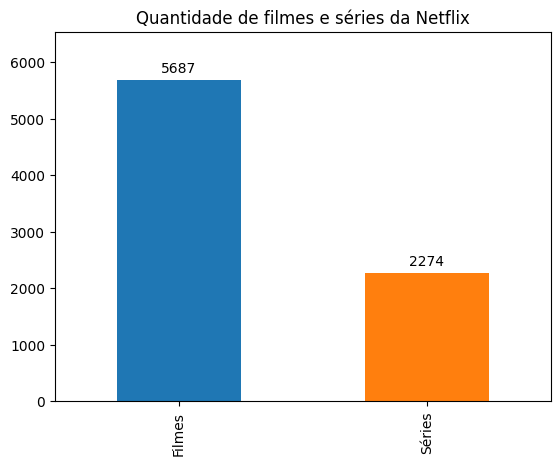

In [ ]:
fig, ax = plt.subplots()
ax = tipo.plot(kind='bar', color=['#1f77b4', '#ff7f0e'], ax=ax)
ax.set_title('Quantidade de filmes e séries da Netflix')
ax.set_xticks(range(len(tipo)))
ax.set_xticklabels(['Filmes', 'Séries'])
ax.set_xlabel('')

for container in ax.containers:
  ax.bar_label(container, fmt='%d', padding=3)

ymax = max(p.get_height() for p in ax.patches)
ax.set_ylim(0, ymax * 1.15)


2. Vamos ver agora a distribuição filmes e séries da Netflix por país:

In [ ]:
pais = df.pais.value_counts().head(10)

(0.0, 3682.2999999999997)

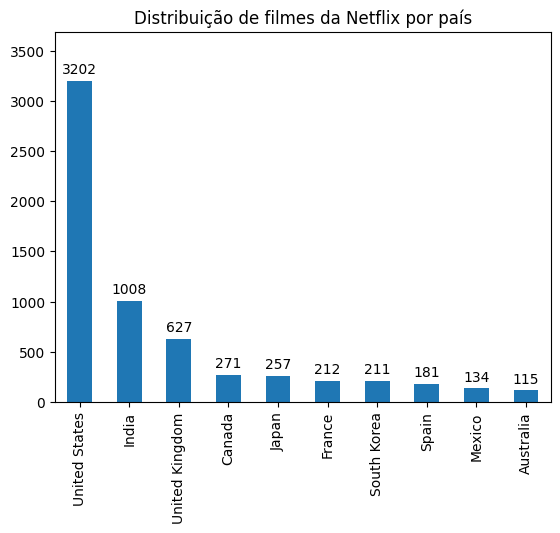

In [ ]:
fig, ax = plt.subplots()
ax = pais.plot(kind='bar')
ax.set_title('Distribuição de filmes da Netflix por país')
ax.set_xticks(range(len(pais)))
ax.set_xlabel('')

for container in ax.containers:
  ax.bar_label(container, fmt='%d', padding=3)

ymax = max(p.get_height() for p in ax.patches)
ax.set_ylim(0, ymax * 1.15)